In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

In [2]:
from sklearn.preprocessing import StandardScaler

import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import numpy as np
import importlib
from functools import partial
import random
import copy
from cross_common import MEE,MSE,RMSE,MAE,R2

importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [3]:
# Change this value manually for repeated evaluations: 1, 10, 20.
TRAINING_SEED = 1
#TRAINING_SEED = 10
#TRAINING_SEED = 20

nnc.set_global_seed(TRAINING_SEED)

<h1>NN - Manual</h1>
<h2>Exploring the CUP dataset with a neural network regressor.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [4]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()

# The train set used for model selection
X_ts, y_ts = cc.prepare_dataset(df_test)

# Split the 500 labelled samples:
# - 80% development set for model selection and cross-validation
# - 20% internal test set for the final independent assessment
(
    X_tr, y_tr, # The train set
    X_internal_ts, y_internal_ts # The internal test set
 ) = (
    # by default 'prepare for hold out' split into 80% - 20%
    cc.prepare_dataset_for_hold_out(df_train,random_state=cc.INTERNAL_TEST_RANDOM_STATE)
)

# To be used for internal test
# this repetition is due to the fact that the most of the NN phases
# requires the set to be not scaled, because the scaling is done internally
# while the internal test is done on a scaled set
internal_scaler = StandardScaler()
(
    X_tr_scaled, _, # The train set
    X_internal_ts_scaled, _ # The internal test set
 ) = cc.prepare_dataset_for_hold_out(df_train, scaler=internal_scaler, random_state=cc.INTERNAL_TEST_RANDOM_STATE)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,400,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [5]:
# Optuna parameters
optuna_epochs = 1000

# ---------- Optuna search space result ------------
run_1_selected_config = {
    "hidden_layers": [256],
    "activation": "tanh",
    "batch_size": 64,
    "learning_rate": 0.10854786341445802,
    "weight_decay": 4.6677577661674666e-05,
}

# Best verified configuration
run_2_selected_config = {
    "hidden_layers": [128, 64],
    "activation": "gelu",
    "batch_size": 16,
    "learning_rate": 0.0467814685218321,
    "weight_decay": 0.006545327900225643,
}

run_3_selected_config = {
    "hidden_layers": [64, 64],
    "activation": "gelu",
    "batch_size": 32,
    "learning_rate": 0.1089031840661933,
    "weight_decay": 5.273579364264809e-06,
}
# --------------------------------------------------

#run_config = run_1_selected_config
run_config = run_2_selected_config
#run_config = run_3_selected_config

optuna_learning_rate = run_config["learning_rate"]
optuna_weight_decay = run_config["weight_decay"]
optuna_hidden_layers = run_config["hidden_layers"]
optuna_activation = run_config["activation"]
optuna_batch_size = run_config["batch_size"]

# The seed to be used by data splitter
CV_RANDOM_STATE = cr.RANDOM_STATE
HOLD_OUT_SEED = cr.SEED


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = optuna_hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, optuna_activation)

# The output and loss function, must be changed according to the type of task
#loss_function = nn.MSELoss()
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=optuna_learning_rate,
    weight_decay=optuna_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5 #0.7    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---- The additional metrics to compute ---
metrics_dict = {
    # The loss function is implicitly added during training
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    #R2: (cr.r2,max),
}
the_metrics = [cr.LOSS] + list(metrics_dict.keys())
# ------------------------------------------


<h3>NN Run</h3>
<p>The NN run is separated in two distinct scenarios independent from each other:
<ol>
<li>Hold-out: meant to be used for inspecting the correctness of the whole pipeline (i.e. no error, effectiveness of learning rate decay, plotting etc...).</li>
<li>KFold: meant to be used for model selection and asessment eventually leading to testing evaluation.</li>
</ol>
</p>
<hr/>

<h4>KFold</h4>
<p>Model selection is performed using K-Fold cross-validation on the training data, while an initial hold-out split was used only for preliminary analysis and debugging.</p>

<h5>Run</h5>

In [6]:
# The KFold strategy to be used through all models
outer_cv = cr.common_fold_strategy(n_split=5, random_state=CV_RANDOM_STATE)

seed_evaluation_results = {}
seed_fold_histories = {}

inner_train_params = {
    "epochs": optuna_epochs,
    "batch_size": optuna_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, outer_cv, inner_train_params, scaler
)


  
Perform fold: 0, train size: 320, val size: 80
Early stopping at epoch 134 (best VL loss: 19.8910)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 320
Validation      | samples: 80
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0467814685218321, 'weight_decay': 0.006545327900225643, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 85 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 320, val size: 80
Early stopping at epoch 94 (best VL loss: 21.7442)
Train summary
-----------------------------

In [7]:
# Target training loss: the average training loss observed at the validation-optimal epoch across the cross-validation folds,
# used as the stopping threshold for final full-data retraining.
target_training_loss = nnc.find_target_training_loss(fold_histories)
print(target_training_loss)


15.696065902709961


<h5>Training</h5>
<p>Training the model.</p>

In [8]:
median_best_epoch = nnc.find_best_median_epochs(fold_histories)
print(median_best_epoch)

71


In [9]:
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.44424819946289
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-34.0255928  -36.09343338 -35.34489059 -35.34389114 -36.41343307]


<h5>Metrics</h5>
<p>Main metrics used for model assessment.
</p>

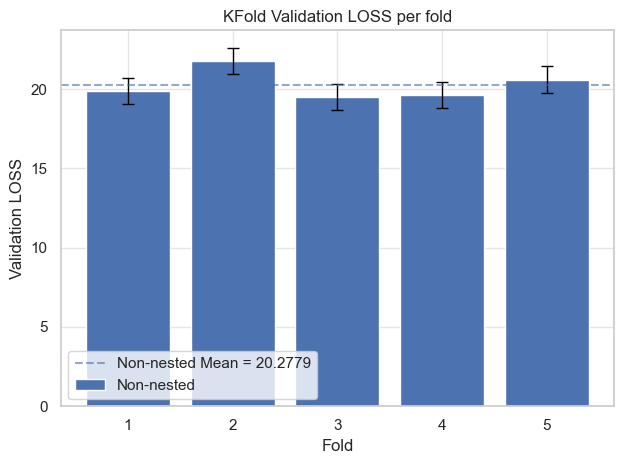

,TR,VL,|TR-VL|
Fold,,,
1,14.400051,19.890970,5.490919
2,18.130165,21.744241,3.614076
3,15.181595,19.517163,4.335568
4,14.641933,19.635820,4.993886
5,16.126585,20.601548,4.474963
MEAN,15.696066,20.277948,4.581882
STD,1.353936,0.824088,0.633221


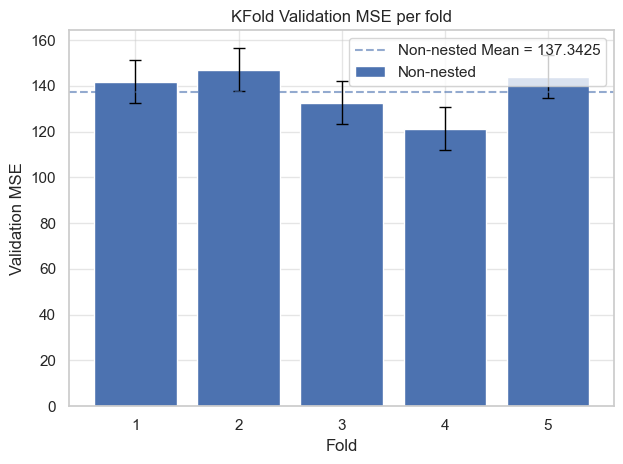

,TR,VL,|TR-VL|
Fold,,,
1,79.403355,141.763385,62.360030
2,110.478964,147.018387,36.539423
3,85.252666,132.572191,47.319525
4,83.502862,121.318517,37.815655
5,95.504806,144.040100,48.535294
MEAN,90.828531,137.342516,46.513985
STD,11.165101,9.354665,9.284229


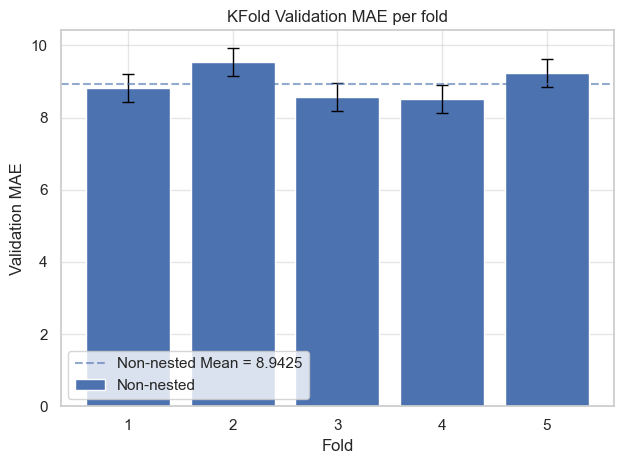

,TR,VL,|TR-VL|
Fold,,,
1,6.039995,8.830478,2.790484
2,8.030115,9.532541,1.502426
3,6.700430,8.577349,1.876919
4,6.443872,8.526849,2.082977
5,7.095208,9.245429,2.150221
MEAN,6.861924,8.942529,2.080605
STD,0.677570,0.389504,0.420609


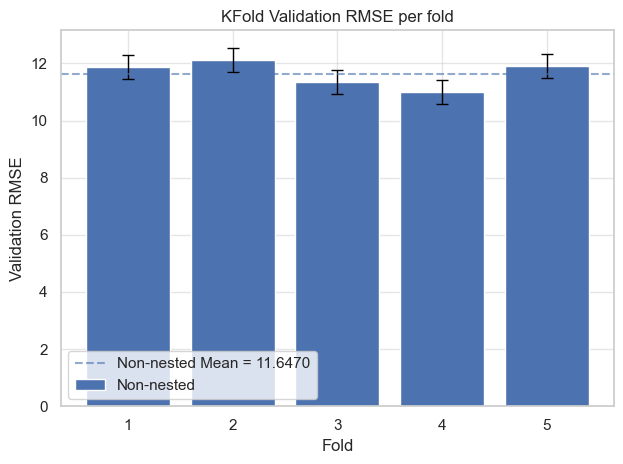

,TR,VL,|TR-VL|
Fold,,,
1,8.750776,11.870091,3.119315
2,10.402436,12.117314,1.714877
3,9.167037,11.342070,2.175033
4,9.048127,10.997162,1.949035
5,9.653620,11.908586,2.254966
MEAN,9.404399,11.647045,2.242645
STD,0.577699,0.413440,0.477078


In [10]:
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))

<h4>Hold-out</h4>
<p>A fixed hold-out split is used exclusively for diagnostic purposes: to visualize the training and validation learning curves, assess convergence and generalization behavior, and illustrate the epoch selected by early stopping. It is not used for hyperparameter selection or final model assessment.</p>

In [11]:
importlib.reload(nnc)
importlib.reload(cr)
model_holdout = copy.deepcopy(model_template)
inner_train_params_holdout = copy.deepcopy(inner_train_params)
hold_out_scaler = StandardScaler()

hold_out_result = nnc.train(
    model_holdout, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), seed=HOLD_OUT_SEED, scaler=hold_out_scaler),
    **inner_train_params_holdout
)

Early stopping at epoch 107 (best VL loss: 20.0793)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 320
Validation      | samples: 80
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0467814685218321, 'weight_decay': 0.006545327900225643, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 58 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [12]:
epochs_tr_mee = hold_out_result.epochs_tr_loss
epochs_vl_mee = hold_out_result.epochs_vl_loss
epochs_grad = hold_out_result.epochs_grad_norm
best_hold_out_epoch = hold_out_result.best_epoch

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

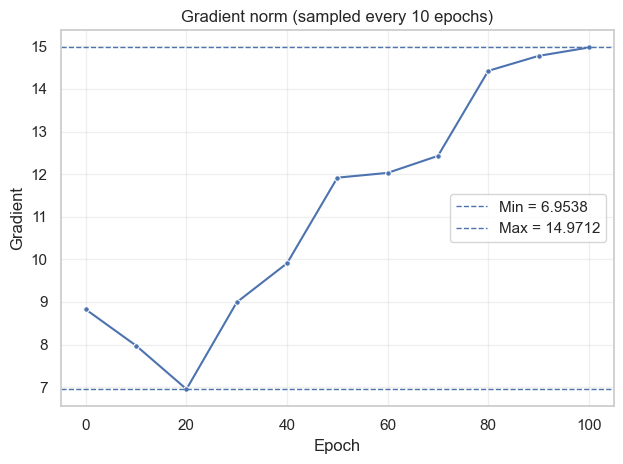

In [13]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

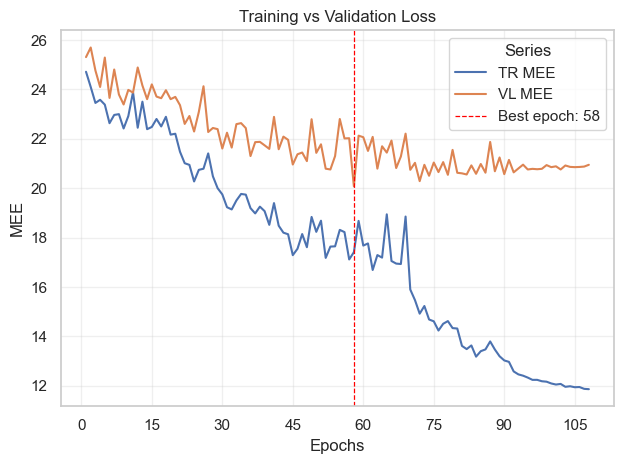

In [14]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_tr_mee, epochs_vl_mee, best_hold_out_epoch)

In [15]:
best_vl_mee = min(hold_out_result.epochs_vl_loss)
best_epoch = hold_out_result.epochs_vl_loss.index(best_vl_mee)
print(f"min MEE: {best_vl_mee} - best epoch: {best_epoch+1}")

min MEE: 20.079291534423827 - best epoch: 58


<h4>Bootstrap-OOB Stability Analysis</h4>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [16]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 100
bootstrap_rstate = cr.RANDOM_STATE
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
#bootstrap_params['train_params']["epochs"] = median_best_epoch
bootstrap_params["train_params"]["train_control"] = target_training_loss
bootstrap_params['scaler'] = StandardScaler()
bootstrap_params['split_strategy'] = nnc.FullTrainingStrategy
bootstrap_params['train_params'].pop("scheduler_template", None)
bootstrap_params['train_params'].pop("early_stopping_strategy", None)
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

In [17]:
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MEE,22.72,1.09,4.78


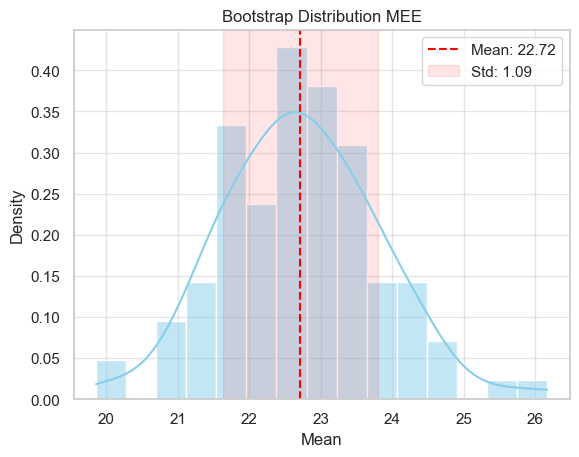

In [18]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {MEE.upper()}")

In [19]:
save_report = False
if save_report:
    metrics={}
    for metric, value in zip(["mee", "mse", "mae"],[
        ([f.fold_vl_mee for f in fold_histories],[f.fold_tr_mee for f in fold_histories]),
        ([f.fold_vl_mse for f in fold_histories],[f.fold_tr_mse for f in fold_histories]),
        ([f.fold_vl_mae for f in fold_histories],[f.fold_tr_mae for f in fold_histories])
        ]):

        metrics[metric] = (cr.mean_std_from_kfold(value[0]), cr.mean_std_from_kfold(value[1]))
        nnc.save_run_report(model_baseline, net,inner_train_params,metrics)

<h4>Final model</h4>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on internal test set.</p>
<p><b>Important!!! This internal test set is accessed and evaluated only after the model configuration, hyperparameters, training procedure, and random seed have been frozen, ensuring an independent and unbiased final assessment.</b></p>

In [20]:
model_final = copy.deepcopy(model_template)
inner_train_params_final = copy.deepcopy(inner_train_params)
# For full retraining we rely on the target train loss at the best epoch VL
# instead of using early stopping and scheduler template
inner_train_params_final.pop("scheduler_template")
inner_train_params_final.pop("early_stopping_strategy")
inner_train_params_final["train_control"] = target_training_loss

train_final_result = nnc.train(
    model_final, nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_tr_scaled, y_tr)),
    **inner_train_params_final
)

Train control at epoch 171 (15.523565635681152 <= 15.696065902709961)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: None
Train control   | limit: 15.696065902709961
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0467814685218321, 'weight_decay': 0.006545327900225643, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


In [21]:
y_pred_tr = (model_final.predict(X_tr_scaled)[0].detach().cpu().numpy())
y_pred_internal = (model_final.predict(X_internal_ts_scaled)[0].detach().cpu().numpy())

mee_tr = cr.mee(y_tr, y_pred_tr)
mee_internal = cr.mee(y_internal_ts, y_pred_internal)

print(f"Training MEE:      {mee_tr:.4f}")
print(f"Internal Test MEE: {mee_internal:.4f}")

Training MEE:      15.5236
Internal Test MEE: 22.8320
